---
title: "The AEMET monthly archive — what we actually downloaded"
short_title: "AEMET archive overview"
---

# The AEMET monthly archive

This notebook is a tour of the GeoParquet archive built by
`scripts/observations/aemet/monthly.py`: what is in it, how its coverage is
distributed in space and time, and what that distribution means for anyone
who wants to compute a trend from it.

**Provenance.** AEMET OpenData's monthly climatological endpoint, walked in
two-year windows at 60 requests/minute. The archive was filled in two runs —
1920–1954 in May 2026, then 1955–2019 on 2026-08-20 — and is cached as a
single long-format GeoParquet file. Nothing here touches the network; every
figure reads the cache.

**The one thing to take away.** The station network grew roughly 40-fold
across the record, from ~20 reporting stations in the 1920s to ~810 in the
2010s. Any statistic computed over "all stations reporting in year $y$" is
therefore a statistic about a *different network* each year, and the change
in the network can easily outweigh the change in the climate. Section 4
shows this failure directly and then does it properly with a fixed panel.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import geopandas as gpd
from benchmark.observations.aemet.paths import scratch_root

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.autolayout": True,
    }
)

ARCHIVE = scratch_root() / "monthly"
print("archive:", ARCHIVE)


# Spain plots badly in raw lon/lat: the Canaries sit ~1500 km south-west of
# the peninsula, so a single frame containing both gives the mainland about a
# third of the width. Spanish maps conventionally box the islands into an
# inset, which is what this helper does.
PENINSULA = ((-9.8, 4.6), (35.7, 44.0))
CANARIES = ((-18.3, -13.2), (27.4, 29.6))
ASPECT = 1 / np.cos(np.deg2rad(40))


def spain_map(ax, lon, lat, values, *, inset=True, **kwargs):
    """Scatter station values over the peninsula, Canaries in an inset.

    Returns the peninsula PathCollection so a colorbar can be attached.
    Both axes share the caller's vmin/vmax, so colours are comparable.
    """
    handle = ax.scatter(lon, lat, c=values, **kwargs)
    ax.set(xlim=PENINSULA[0], ylim=PENINSULA[1])
    ax.set_aspect(ASPECT)

    if not inset:
        return handle

    # bottom-right corner is open Mediterranean — it hides no stations,
    # whereas the conventional bottom-left placement covers ~36 in Andalucía
    box = ax.inset_axes([0.69, 0.02, 0.30, 0.235])
    box.scatter(lon, lat, c=values, **kwargs)
    box.set(xlim=CANARIES[0], ylim=CANARIES[1], xticks=[], yticks=[])
    box.set_aspect(ASPECT)
    box.grid(False)
    for spine in box.spines.values():
        spine.set(visible=True, linewidth=0.8, color="0.45")
    box.set_title("Canarias", fontsize=7, pad=1.5, color="0.3")
    return handle

archive: /home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/aemet/monthly


## 1. Loading the archive

Two files: the observations in long format (one row per station-month) and
the station inventory as a GeoParquet point layer.

In [2]:
obs = pd.read_parquet(ARCHIVE / "aemet_monthly.parquet")
obs["time"] = pd.to_datetime(obs["time"])
obs["year"] = obs["time"].dt.year
obs["month"] = obs["time"].dt.month

stations = gpd.read_parquet(ARCHIVE / "stations.parquet")

print(f"observations : {len(obs):,} rows x {obs.shape[1]} columns")
print(f"period       : {obs.year.min()}-{obs.year.max()}")
print(f"stations      : {obs.station_id.nunique()} in the data, {len(stations)} in the live inventory")
print(f"CRS           : {stations.crs.to_string()} ({stations.crs.name})")

observations : 1,116,120 rows x 17 columns
period       : 1920-2019
stations      : 949 in the data, 921 in the live inventory
CRS           : EPSG:4326 (WGS 84)


The data holds **949** distinct stations while the live inventory advertises
**921**. That gap is not an error: AEMET retires and renumbers stations, so
28 stations in the archive no longer exist in the API's current list. The
scrape's `merged_inventory()` re-adds them precisely so that resuming a
historical window does not silently drop them.

### Which variables are actually populated?

The schema is wider than the data. A station-month row exists for every
station in every window that was scraped, whether or not that station
reported anything, so the table is mostly empty by construction.

In [3]:
meta_cols = {"station_id", "time", "lon", "lat", "geometry", "year", "month"}
variables = [c for c in obs.columns if c not in meta_cols]

filled = (
    pd.DataFrame(
        {
            "non_null": [obs[c].notna().sum() for c in variables],
            "pct_of_rows": [obs[c].notna().mean() * 100 for c in variables],
        },
        index=variables,
    )
    .sort_values("non_null", ascending=False)
    .round({"pct_of_rows": 1})
)
filled

,non_null,pct_of_rows
precipitation_amount,209281,18.8
air_temperature_daily_min,197445,17.7
air_temperature_daily_max,197388,17.7
air_temperature_daily_mean,197305,17.7
wind_speed_daily_mean,150670,13.5
surface_pressure_hpa,81227,7.3
surface_pressure_max_hpa,79991,7.2
surface_pressure_min_hpa,79886,7.2
sunshine_duration_daily,72840,6.5
wind_speed_of_gust_daily,0,0.0


Precipitation and the three temperature variables are the usable core, at
~18% of rows each. Pressure and sunshine are roughly a third as dense.
**`wind_speed_of_gust_daily` is entirely empty** — the column exists in the
preset but the monthly endpoint never populates it, so treat it as absent
rather than as missing data.

The 18% figure is not a data-quality problem so much as a shape problem: it
is the product of a wide station axis and a long time axis that only overlap
in recent decades. The rest of the notebook is largely about that overlap.

## 2. The station network

921 live stations across 19 autonomous communities and 52 provinces, from
sea level to just over 3000 m.

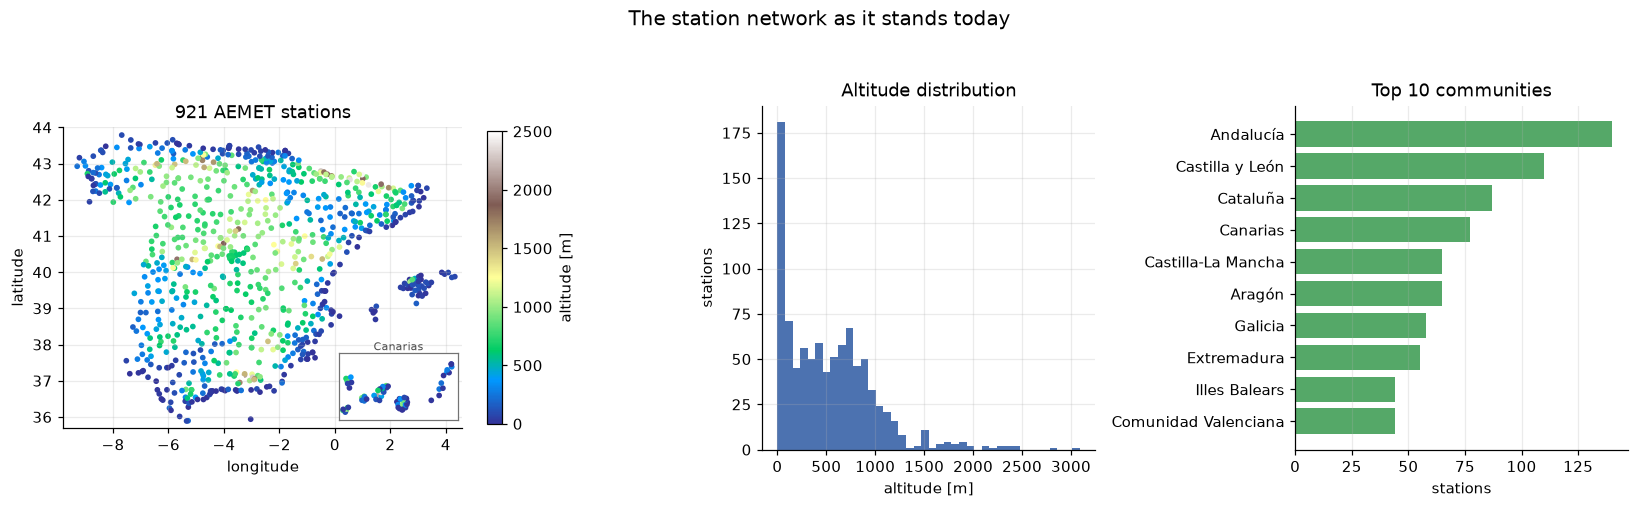

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.5, 1, 1]})

ax = axes[0]
sc = spain_map(ax, stations.geometry.x, stations.geometry.y, stations.altitude,
               cmap="terrain", s=14, edgecolor="none", vmin=0, vmax=2500)
ax.set(xlabel="longitude", ylabel="latitude", title=f"{len(stations)} AEMET stations")
fig.colorbar(sc, ax=ax, label="altitude [m]", shrink=0.85)

ax = axes[1]
ax.hist(stations.altitude.dropna(), bins=40, color="#4C72B0")
ax.set(xlabel="altitude [m]", ylabel="stations", title="Altitude distribution")

ax = axes[2]
top = stations.community.value_counts().head(10)[::-1]
ax.barh(top.index, top.values, color="#55A868")
ax.set(xlabel="stations", title="Top 10 communities")
ax.grid(axis="y", visible=False)
fig.suptitle("The station network as it stands today", y=1.04, fontsize=13)
plt.show()

The geography is immediately legible: the dense interior ring around the
Meseta, the coastal strings along the Mediterranean, and the two island
groups. The Canaries sit roughly 1500 km south-west of the peninsula, so
they are boxed into the usual inset — plotting both in one frame would give
the mainland about a third of the width.

Altitude is strongly right-skewed: most stations sit below 800 m, with a
thin tail into the Pyrenees and Sierra Nevada. That tail matters in §5,
where it lets us recover the environmental lapse rate.

## 3. Coverage in time — the network is not constant

This is the figure that governs how the archive may be used.

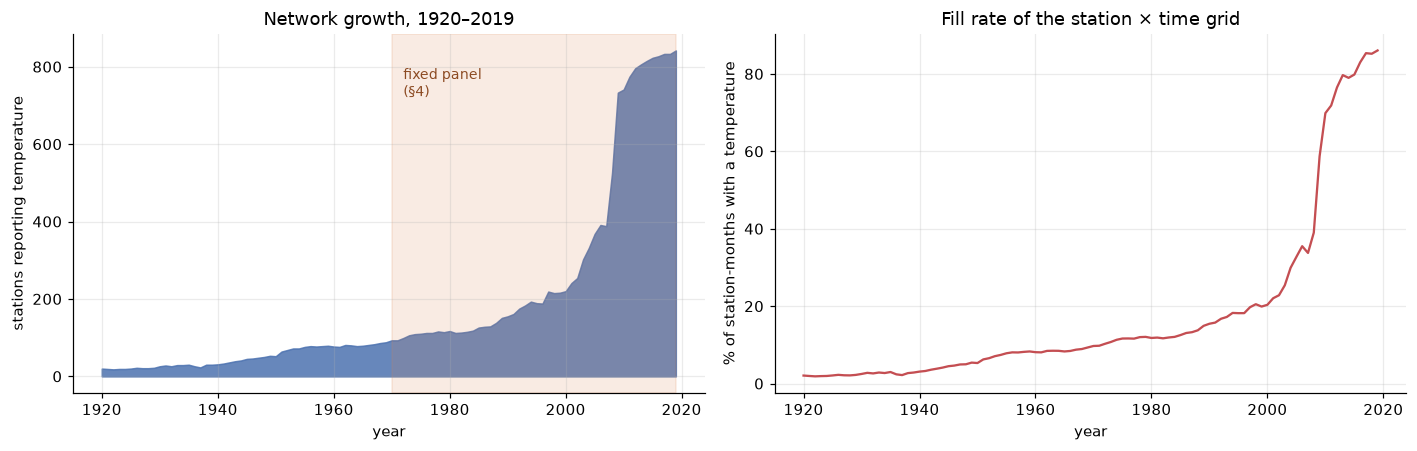

mean stations reporting temperature, by decade
  1920s:    20
  1930s:    28
  1940s:    42
  1950s:    72
  1960s:    81
  1970s:   106
  1980s:   125
  1990s:   189
  2000s:   375
  2010s:   809


In [5]:
temp = obs.dropna(subset=["air_temperature_daily_mean"])
per_year = temp.groupby("year").station_id.nunique()
rows_per_year = obs.groupby("year").size()
filled_per_year = temp.groupby("year").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.fill_between(per_year.index, per_year.values, color="#4C72B0", alpha=0.85)
ax.set(xlabel="year", ylabel="stations reporting temperature",
       title="Network growth, 1920–2019")
ax.axvspan(1970, 2019, color="#DD8452", alpha=0.16)
ax.text(1972, per_year.max() * 0.86, "fixed panel\n(§4)", color="#8C4A22", fontsize=9)

ax = axes[1]
ax.plot(rows_per_year.index, filled_per_year / rows_per_year * 100, color="#C44E52")
ax.set(xlabel="year", ylabel="% of station-months with a temperature",
       title="Fill rate of the station × time grid")
plt.show()

print("mean stations reporting temperature, by decade")
for decade in range(1920, 2020, 10):
    print(f"  {decade}s: {per_year.loc[decade:decade + 9].mean():5.0f}")

Two views of the same fact. On the left, the reporting network grows from
~20 stations to ~840, with a step change around 2009 when a large tranche of
automatic stations enters the record. On the right, the fill rate of the
rectangular station × time grid rises from ~2% to ~86%.

The rectangle is the reason the archive is 82% empty overall: it has 949
station slots for every month back to 1920, and almost none of those
stations existed then. It is a storage artefact, not missing observations.

## 4. Temperature trends — and how to get them wrong

The tempting move is to average every station reporting in each year and
call the result a national mean. Because the network changes composition
every year, that series mostly measures *which stations were added*.

The fix is a **fixed panel**: pick stations with near-complete records over
a chosen window, convert each to an anomaly against its own climatology, and
average only those. Anomalies remove the station's mean altitude and
latitude, so the panel average is a change signal rather than an absolute.

In [6]:
WINDOW = (1970, 2019)
BASELINE = (1981, 2010)

span = temp[temp.year.between(*WINDOW)]
months_possible = (WINDOW[1] - WINDOW[0] + 1) * 12
counts = span.groupby("station_id").size()
panel_ids = counts[counts >= 0.95 * months_possible].index

panel = span[span.station_id.isin(panel_ids)].copy()
clim = (
    panel[panel.year.between(*BASELINE)]
    .groupby(["station_id", "month"])["air_temperature_daily_mean"]
    .mean()
    .rename("climatology")
)
panel = panel.join(clim, on=["station_id", "month"])
panel["anomaly"] = panel["air_temperature_daily_mean"] - panel["climatology"]

naive = temp.groupby("year")["air_temperature_daily_mean"].mean()
panel_annual = panel.groupby("year")["anomaly"].mean()

slope, intercept = np.polyfit(panel_annual.index, panel_annual.values, 1)

# The same window, computed the naive way, for a like-for-like comparison.
naive_window = naive.loc[WINDOW[0]:WINDOW[1]]
naive_slope = np.polyfit(naive_window.index, naive_window.values, 1)[0]

print(f"panel: {len(panel_ids)} stations with >=95% monthly coverage {WINDOW[0]}-{WINDOW[1]}")
print(f"  fixed panel : {slope * 10:+.3f} K/decade "
      f"({slope * (WINDOW[1] - WINDOW[0]):+.2f} K over the window)")
print(f"  naive mean  : {naive_slope * 10:+.3f} K/decade  "
      f"({(1 - naive_slope / slope) * 100:.0f}% lower)")

panel: 59 stations with >=95% monthly coverage 1970-2019
  fixed panel : +0.384 K/decade (+1.88 K over the window)
  naive mean  : +0.247 K/decade  (36% lower)


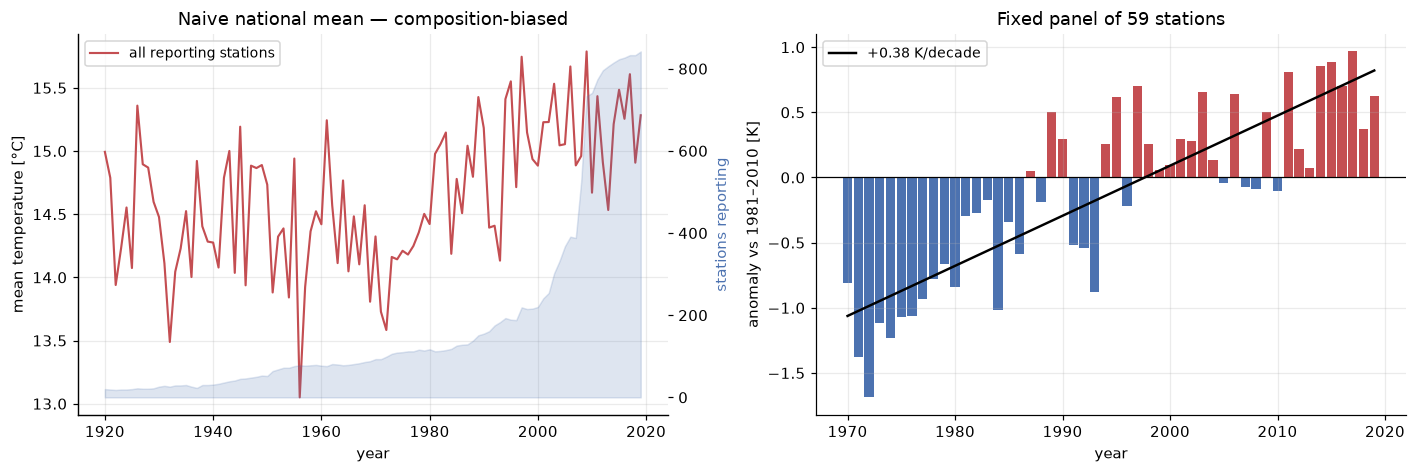

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.plot(naive.index, naive.values, color="#C44E52", lw=1.4, label="all reporting stations")
ax.set(xlabel="year", ylabel="mean temperature [°C]",
       title="Naive national mean — composition-biased")
twin = ax.twinx()
twin.fill_between(per_year.index, per_year.values, color="#4C72B0", alpha=0.18)
twin.set_ylabel("stations reporting", color="#4C72B0")
twin.grid(False)
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
colors = np.where(panel_annual.values >= 0, "#C44E52", "#4C72B0")
ax.bar(panel_annual.index, panel_annual.values, color=colors, width=0.85)
fit = slope * panel_annual.index + intercept
ax.plot(panel_annual.index, fit, color="black", lw=1.6,
        label=f"{slope * 10:+.2f} K/decade")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="year", ylabel=f"anomaly vs {BASELINE[0]}–{BASELINE[1]} [K]",
       title=f"Fixed panel of {len(panel_ids)} stations")
ax.legend(loc="upper left", fontsize=9)
plt.show()

Both series warm, but by different amounts. Over the identical 1970–2019
window the naive mean gives **+0.25 K/decade** against the fixed panel's
**+0.38 K/decade** — it understates the warming by about a third, because
the stations added along the way are not a random sample of the ones
already there. Its year-to-year swings are also a mixture of real weather
and network turnover, so an individual year in the red curve cannot be
interpreted on its own.

The right panel, restricted to 59 stations that reported almost every month
for fifty years, is a change signal for a constant set of sites: about
+1.9 K across the window, flipping from mostly-blue to mostly-red in the
late 1980s, with recent years almost uniformly warm.

Neither series is homogenised: no correction is applied for station moves,
instrument changes, or urban growth around a site. A published national
series would correct for all three. Treat the +0.38 K/decade as the raw
archive's own answer, consistent with the ~0.3–0.4 K/decade generally
reported for Spain, not as an independent estimate.

## 5. Space — climatology, and the lapse rate

Averaging each station over 1990–2019 gives a climatology per site. Requiring
at least 120 station-months keeps stations with only a season or two of data
out of the maps.

In [8]:
recent = obs[obs.year.between(1990, 2019)]
clim_station = recent.groupby("station_id").agg(
    temperature=("air_temperature_daily_mean", "mean"),
    precipitation=("precipitation_amount", "mean"),
    lon=("lon", "first"),
    lat=("lat", "first"),
    n_months=("time", "size"),
)
clim_station = clim_station[clim_station.n_months >= 120].join(
    stations.set_index("id")[["altitude", "community", "province"]]
)
print(f"{len(clim_station)} stations in the 1990–2019 climatology")

921 stations in the 1990–2019 climatology


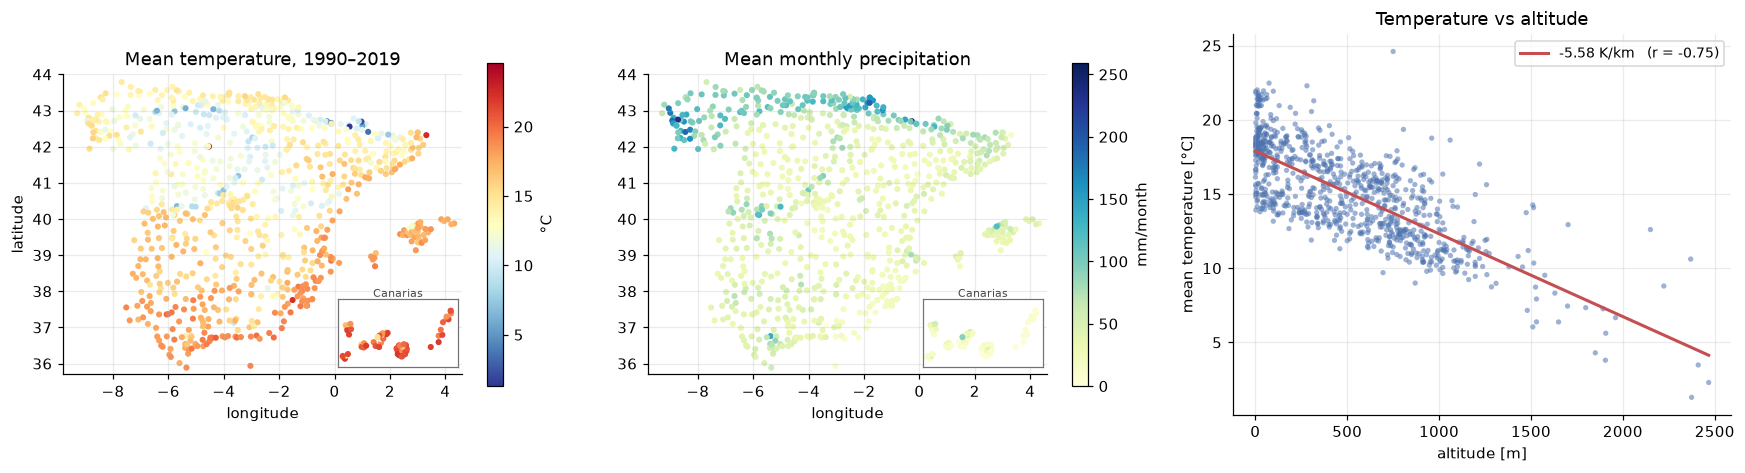

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
sc = spain_map(ax, clim_station.lon, clim_station.lat, clim_station.temperature,
               cmap="RdYlBu_r", s=16, edgecolor="none")
ax.set(title="Mean temperature, 1990–2019", xlabel="longitude", ylabel="latitude")
fig.colorbar(sc, ax=ax, label="°C", shrink=0.85)

ax = axes[1]
sc = spain_map(ax, clim_station.lon, clim_station.lat, clim_station.precipitation,
               cmap="YlGnBu", s=16, edgecolor="none")
ax.set(title="Mean monthly precipitation", xlabel="longitude")
fig.colorbar(sc, ax=ax, label="mm/month", shrink=0.85)

ax = axes[2]
ok = clim_station.dropna(subset=["temperature", "altitude"])
lapse, t0 = np.polyfit(ok.altitude, ok.temperature, 1)
r = np.corrcoef(ok.altitude, ok.temperature)[0, 1]
ax.scatter(ok.altitude, ok.temperature, s=12, alpha=0.55, color="#4C72B0", edgecolor="none")
grid = np.linspace(ok.altitude.min(), ok.altitude.max(), 50)
ax.plot(grid, lapse * grid + t0, color="#C44E52", lw=2,
        label=f"{lapse * 1000:.2f} K/km   (r = {r:.2f})")
ax.set(xlabel="altitude [m]", ylabel="mean temperature [°C]", title="Temperature vs altitude")
ax.legend(fontsize=9)
plt.show()

The temperature map recovers the expected structure: a warm Guadalquivir
valley and Mediterranean fringe, a cool interior Meseta, cold spots in the
Pyrenees and Sierra Nevada, and the Canaries warm year-round.

Precipitation shows the sharper contrast — "Green Spain" along the Atlantic
north coast against the semi-arid south-east around Almería, which is among
the driest inhabited parts of Europe.

The scatter recovers an environmental lapse rate of **−5.6 K/km** with
$r = -0.75$, close to the canonical −6.5 K/km. It falls a little short
because altitude is confounded with latitude and distance from the coast
here — this is a cross-sectional fit over a country, not a sounding.

## 6. Space and time together

### Where is it warming fastest?

The same panel as §4, but keeping each station's own trend instead of
averaging them.

In [10]:
trends = {}
for sid, grp in panel.groupby("station_id"):
    annual = grp.groupby("year")["anomaly"].mean()
    if len(annual) >= 45:
        trends[sid] = np.polyfit(annual.index, annual.values, 1)[0] * 10

trend = pd.Series(trends, name="k_per_decade").to_frame()
trend = trend.join(clim_station[["lon", "lat", "altitude"]])
print(f"{len(trend)} station trends | median {trend.k_per_decade.median():+.2f} K/decade | "
      f"{(trend.k_per_decade > 0).mean() * 100:.0f}% warming")

# Is the spread organised in space, or is it noise? Correlate the trend
# against the obvious geographic candidates before reading any pattern
# into the map.
print("\ncorrelation of trend with:")
for column in ("lon", "lat", "altitude"):
    ok = trend.dropna(subset=[column])
    print(f"  {column:9s} r = {np.corrcoef(ok.k_per_decade, ok[column])[0, 1]:+.2f}")

59 station trends | median +0.37 K/decade | 100% warming

correlation of trend with:
  lon       r = +0.22
  lat       r = +0.11
  altitude  r = +0.13


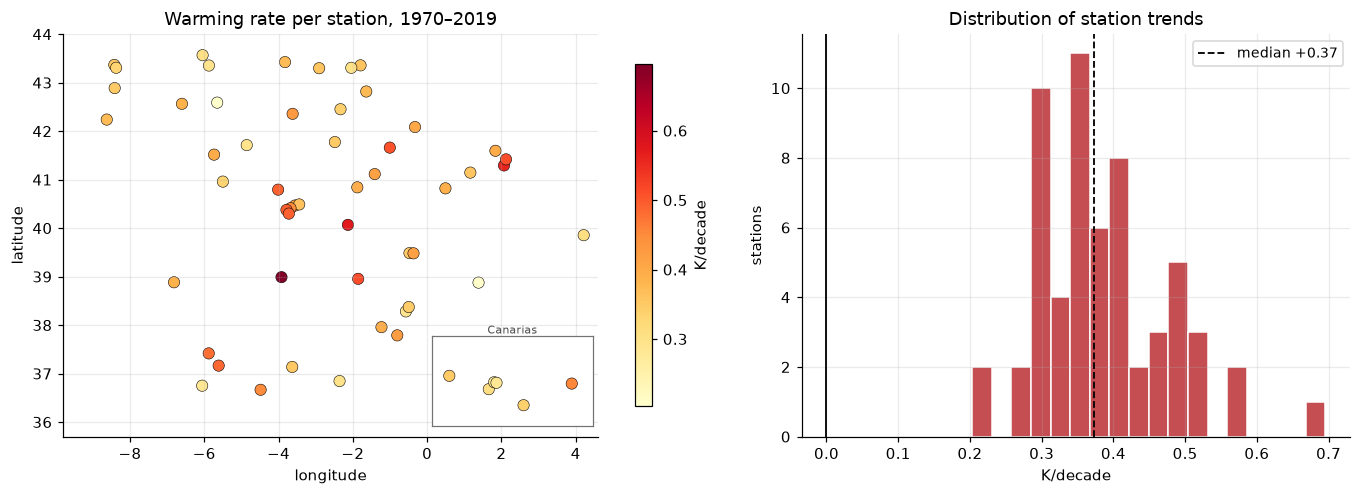

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})

# Every station in the panel is positive, so a diverging scale centred on
# zero would spend half its range on empty colours. Sequential over the
# observed range instead; the histogram carries the "all positive" message.
ax = axes[0]
sc = spain_map(ax, trend.lon, trend.lat, trend.k_per_decade, cmap="YlOrRd",
               vmin=trend.k_per_decade.min(), vmax=trend.k_per_decade.max(),
               s=55, edgecolor="black", linewidth=0.35)
ax.set(title=f"Warming rate per station, {WINDOW[0]}–{WINDOW[1]}",
       xlabel="longitude", ylabel="latitude")
fig.colorbar(sc, ax=ax, label="K/decade", shrink=0.85)

ax = axes[1]
ax.hist(trend.k_per_decade, bins=18, color="#C44E52", edgecolor="white")
ax.axvline(0, color="black", lw=1.2)
ax.axvline(trend.k_per_decade.median(), color="black", ls="--", lw=1.2,
           label=f"median {trend.k_per_decade.median():+.2f}")
ax.set(xlabel="K/decade", ylabel="stations", title="Distribution of station trends")
ax.legend(fontsize=9)
plt.show()

**Every station in the panel warms** — the histogram sits entirely to the
right of zero, spanning roughly +0.2 to +0.7 K/decade. A unanimous sign
across 59 sites is the strongest statement this archive makes.

The *rate* varies threefold across those sites, and it is tempting to read
geography into the map. The correlations above say not to: longitude gives
$r = +0.22$, latitude $+0.11$, altitude $+0.13$, none of which is
distinguishable from noise at $n = 59$. What this panel supports is
"warming everywhere, at a rate that varies", not a spatial pattern. Testing
for one properly needs the full network — which means the denser post-2009
record, over a shorter window.

### Decadal maps

The same climatology recomputed per decade, on a shared colour scale, using
all stations available in each decade. Peninsula only here — six Canaries
insets would clutter the grid without adding much.

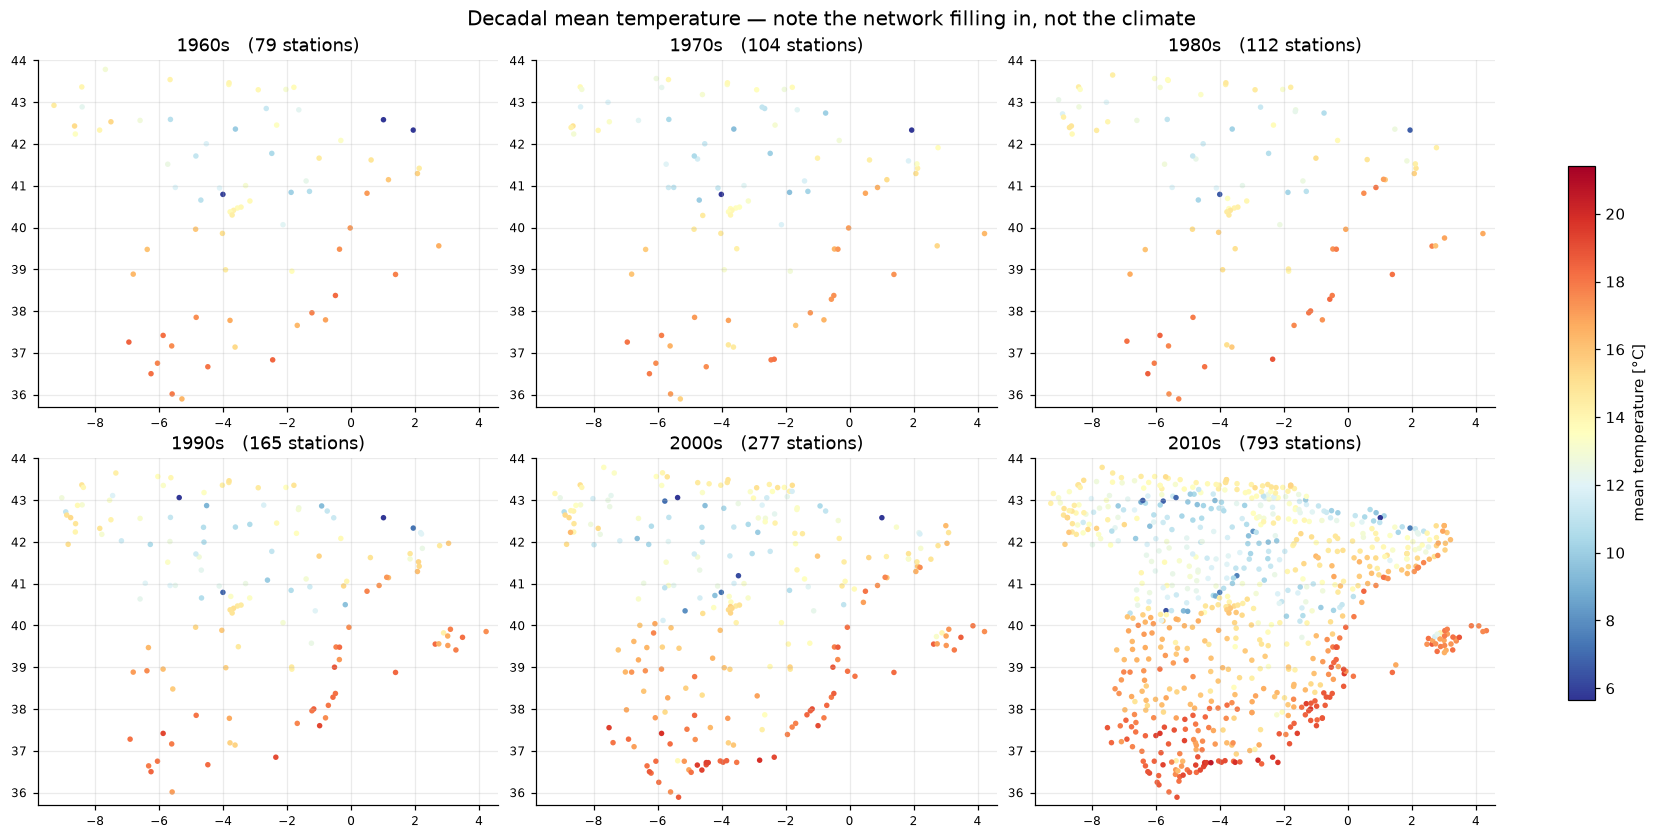

In [12]:
decades = [1960, 1970, 1980, 1990, 2000, 2010]
panels = []
for start in decades:
    chunk = temp[temp.year.between(start, start + 9)]
    agg = chunk.groupby("station_id").agg(
        t=("air_temperature_daily_mean", "mean"),
        lon=("lon", "first"), lat=("lat", "first"), n=("time", "size"))
    panels.append((start, agg[agg.n >= 60]))

vmin = min(p.t.quantile(0.02) for _, p in panels)
vmax = max(p.t.quantile(0.98) for _, p in panels)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), layout="constrained")
fig.set_layout_engine("constrained")
for ax, (start, agg) in zip(axes.ravel(), panels):
    sc = spain_map(ax, agg.lon, agg.lat, agg.t, inset=False, cmap="RdYlBu_r",
                   vmin=vmin, vmax=vmax, s=13, edgecolor="none")
    ax.set(title=f"{start}s   ({len(agg)} stations)")
    ax.tick_params(labelsize=8)
fig.colorbar(sc, ax=axes, label="mean temperature [°C]", shrink=0.7)
fig.suptitle("Decadal mean temperature — note the network filling in, not the climate", fontsize=13)
plt.show()

Read these as a map of *the network*, not of the climate. The dominant
visual change from the 1960s to the 2010s is stations appearing, and the
spatial pattern is essentially fixed. A decade-to-decade temperature change
of a few tenths of a kelvin is invisible next to a colour scale that spans
20 K — which is exactly why the anomaly framing in §4 exists.

### Latitude bands through time

Collapsing longitude gives a Hovmöller-style view: latitude on one axis,
time on the other, anomaly in colour. Bands are 1° wide and each is
expressed against its own 1981–2010 mean, so the panel compares like with
like across very different absolute temperatures.

dropping (35, 36]: median 2 stations — too thin to average


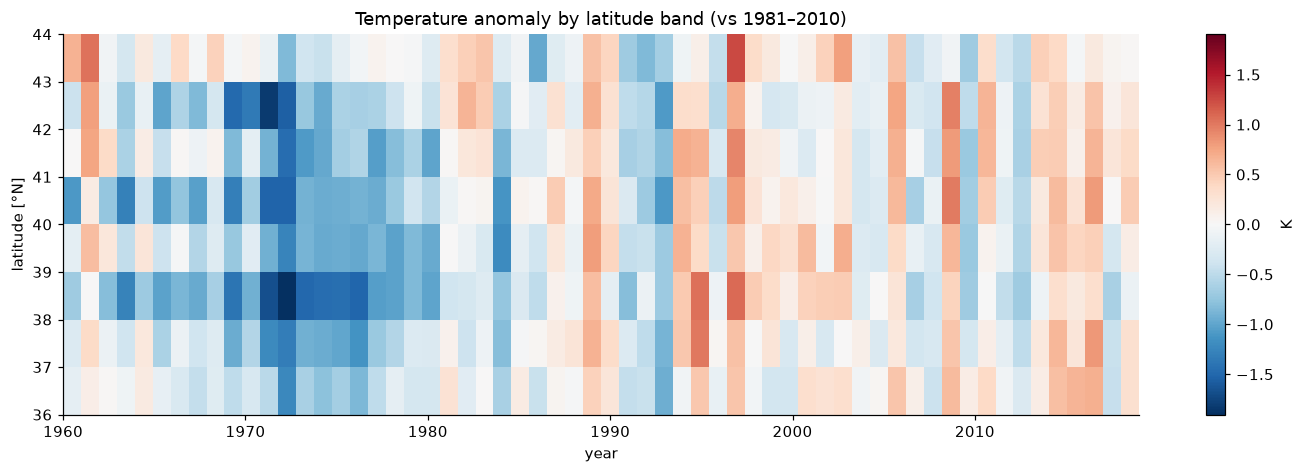

In [13]:
MIN_STATIONS = 5  # per band, median over the window

bands = temp[temp.year >= 1960].copy()
bands["band"] = pd.cut(bands.lat, bins=np.arange(35, 45, 1))

counts = bands.pivot_table(index="band", columns="year", values="station_id",
                           aggfunc="nunique", observed=True)
keep = counts.median(axis=1) >= MIN_STATIONS
for band in counts.index[~keep]:
    print(f"dropping {band}: median {counts.loc[band].median():.0f} stations — too thin to average")

grid = bands.pivot_table(index="band", columns="year",
                         values="air_temperature_daily_mean",
                         aggfunc="mean", observed=True)[keep.values]
baseline = grid.loc[:, 1981:2010].mean(axis=1)
anomaly_grid = grid.sub(baseline, axis=0)

lat_lo = int(grid.index[0].left)
lat_hi = int(grid.index[-1].right)

fig, ax = plt.subplots(figsize=(13, 4.4))
extent = [grid.columns.min(), grid.columns.max(), lat_lo, lat_hi]
limit = np.nanmax(np.abs(anomaly_grid.values))
im = ax.imshow(anomaly_grid.values, aspect="auto", origin="lower", extent=extent,
               cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
ax.set(xlabel="year", ylabel="latitude [°N]",
       title="Temperature anomaly by latitude band (vs 1981–2010)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="K")
plt.show()

The 35–36°N band is dropped automatically: it holds a median of two
stations, and its apparent −3 K excursion in the 1960s was one site's record
rather than a climate signal. With it gone the colour scale spans roughly
±1.9 K and the remaining structure becomes readable.

The blue-to-red transition runs coherently across all eight surviving bands
through the late 1980s and early 1990s, and the 2010s are red nearly
everywhere. Because each band is referenced to its own baseline, this is a
change signal rather than a map of absolute temperature — though the bands
still gain and lose stations over time, so it inherits a weaker form of the
composition problem from §3.

## 7. What to keep in mind when using this archive

1. **The network grew ~40× across the record.** Never average "all stations
   in year $y$" and call it a national series. Use a fixed panel of
   long-record stations, converted to anomalies. §4 shows both.
2. **82% of the table is empty by construction.** The station × time grid is
   rectangular; most stations did not exist for most of it. Filter on
   non-null before computing anything.
3. **`wind_speed_of_gust_daily` is entirely empty** in the monthly preset.
   Pressure and sunshine are about a third as dense as temperature.
4. **Nothing is homogenised.** No adjustment for station relocation,
   instrument change, or urbanisation. Trends here are the raw archive's
   own, not a published national series.
5. **949 stations in the data, 921 in the live inventory.** The 28 retired
   stations are real history, not corruption — see `merged_inventory()`.
6. **2020–2025 is not downloaded yet.** Three two-year windows remain.
   `coverage.py` prints the resume year; §3's coverage plot stops at 2019
   for this reason, and every trend window in this notebook ends there.